In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

In [2]:
image = cv2.imread('IMAGE1.jpg', cv2.IMREAD_GRAYSCALE)

##  Edge Detection using Laplacian of Gaussian (LoG)

In this section, we apply **edge detection** on a grayscale image using the **Laplacian of Gaussian (LoG)** method. This approach combines **noise reduction** and **second-order derivative edge detection**.

---

### 🔹 Step 1: Laplacian of Gaussian Function

We define a function `detect_edges_laplacian_of_gaussian` that performs the following steps:

- **Gaussian Blurring**  
  The image is smoothed using a Gaussian filter to reduce noise and small variations.  
  - Kernel size controls the smoothing window.  
  - Sigma (σ) controls the amount of smoothing.

- **Laplacian Operator**  
  The Laplacian operator computes the second-order spatial derivative of the image, emphasizing regions with rapid intensity changes (edges).

- **Absolute Value & Type Conversion**  
  The absolute value of the Laplacian result is taken and converted to an 8-bit unsigned integer image.

---

### 🔹 Step 2: Edge Detection

The Laplacian of Gaussian is applied to the input image using:
- Kernel size = 5  
- Sigma = 2  

This produces an image where edges appear as strong intensity responses.

---

### 🔹 Step 3: Binary Thresholding

A binary threshold is applied to the edge image:
- Pixels with intensity greater than **5** are set to **255 (white)**  
- Other pixels are set to **0 (black)**  

This step enhances edge visibility by producing a clean binary edge map.

---



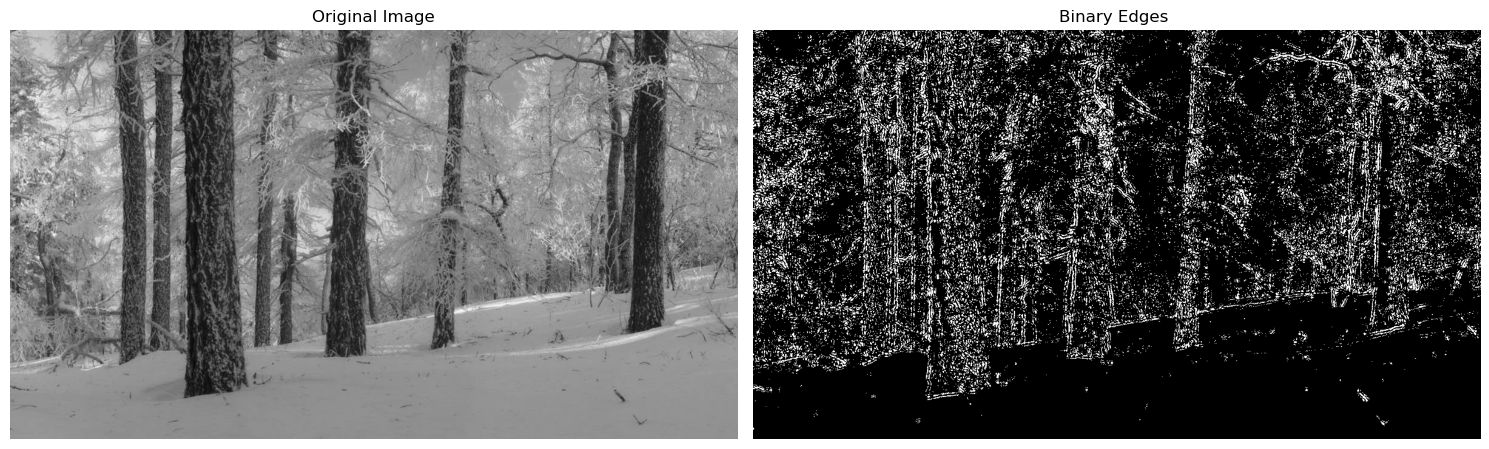

In [32]:
def detect_edges_laplacian_of_gaussian(image, kernel_size, sigma):
    blurred = cv2.GaussianBlur(image, (kernel_size, kernel_size), sigma)
    laplacian = cv2.Laplacian(blurred, cv2.CV_64F)
    edges = np.uint8(np.absolute(laplacian))
    
    return edges


edges = detect_edges_laplacian_of_gaussian(image, kernel_size=5, sigma=2)
_, binary_edges = cv2.threshold(edges, 5, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary_edges, cmap='gray')
plt.title('Binary Edges ')
plt.axis('off')

plt.tight_layout()
plt.show()

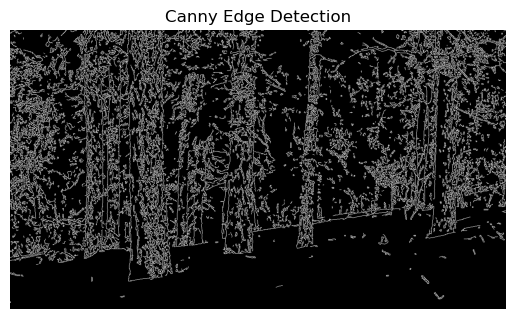

In [14]:
image_contours = cv2.Canny(image, 100, 200)
plt.imshow(image_contours,cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')
plt.show()

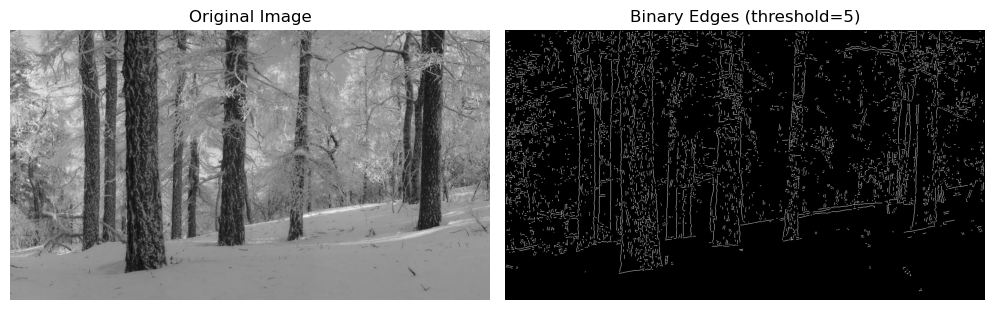

In [18]:
def canny_edge_detector(image, low_threshold=5, high_threshold=70, kernel_size=5, sigma=1.5):
    
    def gaussian_smoothing(img, kernel_size=5, sigma=1.2):
        kernel = np.fromfunction(lambda x, y: (1/(2*np.pi*sigma**2)) *  np.exp(-((x - (kernel_size-1)/2)**2 + (y - (kernel_size-1)/2)**2) / (2*sigma**2)), (kernel_size, kernel_size))
        kernel = kernel / np.sum(kernel)
        pad_size = kernel_size // 2
        padded_img = np.pad(img, pad_size, mode='constant')
        smoothed = np.zeros_like(img, dtype=np.float32)
        
        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                smoothed[i, j] = np.sum(padded_img[i:i+kernel_size, j:j+kernel_size] * kernel)
        
        return smoothed
    
    def calculate_gradients(img):
        sobel_x = np.array([[-1, 0, 1],
                            [-2, 0, 2],
                            [-1, 0, 1]])
        
        sobel_y = np.array([[-1, -2, -1],
                            [0, 0, 0],
                            [1, 2, 1]])
        
        padded_img = np.pad(img, 1, mode='constant')
        grad_x = np.zeros_like(img, dtype=np.float32)
        grad_y = np.zeros_like(img, dtype=np.float32)
        
        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                grad_x[i, j] = np.sum(padded_img[i:i+3, j:j+3] * sobel_x)
                grad_y[i, j] = np.sum(padded_img[i:i+3, j:j+3] * sobel_y)
        
        gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)
        gradient_direction = np.arctan2(grad_y, grad_x) * 180 / np.pi
        
        gradient_direction = gradient_direction % 180
        
        return gradient_magnitude, gradient_direction, grad_x, grad_y
    
    def non_maximum_suppression(magnitude, direction):
        suppressed = np.zeros_like(magnitude)
        
        for i in range(1, magnitude.shape[0]-1):
            for j in range(1, magnitude.shape[1]-1):
                angle = direction[i, j]
                
                if (0 <= angle < 22.5) or (157.5 <= angle <= 180):
                    neighbors = [magnitude[i, j-1], magnitude[i, j+1]]
                elif 22.5 <= angle < 67.5:
                    neighbors = [magnitude[i-1, j+1], magnitude[i+1, j-1]]
                elif 67.5 <= angle < 112.5:
                    neighbors = [magnitude[i-1, j], magnitude[i+1, j]]
                else:  # 112.5 <= angle < 157.5
                    neighbors = [magnitude[i-1, j-1], magnitude[i+1, j+1]]
                
                if magnitude[i, j] >= max(neighbors):
                    suppressed[i, j] = magnitude[i, j]
        
        return suppressed
    
    def hysteresis_thresholding(img, low_thresh, high_thresh):
        strong_edges = (img >= high_thresh)
        weak_edges = (img >= low_thresh) & (img < high_thresh)
        result = strong_edges.astype(np.uint8) * 255
        
        for i in range(1, img.shape[0]-1):
            for j in range(1, img.shape[1]-1):
                if weak_edges[i, j]:
                    if np.any(strong_edges[i-1:i+2, j-1:j+2]):
                        result[i, j] = 255
        
        return result
    
    if image.dtype != np.float32:
        image = image.astype(np.float32)
    smoothed = gaussian_smoothing(image, kernel_size, sigma)
    gradient_mag, gradient_dir, grad_x, grad_y = calculate_gradients(smoothed)
    suppressed = non_maximum_suppression(gradient_mag, gradient_dir)
    edges = hysteresis_thresholding(suppressed, low_threshold, high_threshold)
    
    return edges, gradient_mag, suppressed


edges , gradient_mag , supressed = canny_edge_detector(image)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(edges, cmap='gray')
plt.title('Binary Edges (threshold=5)')
plt.axis('off')

plt.tight_layout()
plt.show()

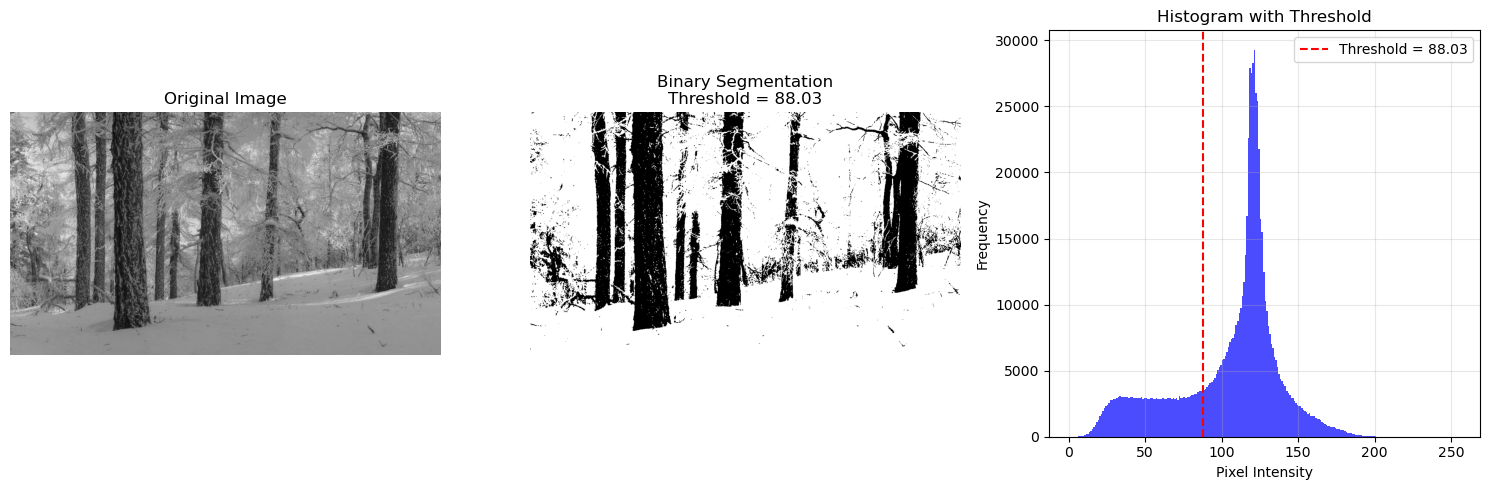

In [24]:
def averaging_threshold_method(img, initial_threshold=76, delta=0.5, max_iterations=100):
    
    S = initial_threshold
    iteration = 0
    
    while iteration < max_iterations:
        class1 = img[img >= S]  
        class2 = img[img < S]   
        
        if len(class1) > 0:
            m1 = np.mean(class1)
        else:
            m1 = 0
            
        if len(class2) > 0:
            m2 = np.mean(class2)
        else:
            m2 = 0
        
        S_new = (m1 + m2) / 2
        
        if abs(S - S_new) < delta:
            S = S_new
            break
        
        S = S_new
        iteration += 1
    
    binary_img = np.where(img >= S, 1, 0).astype(np.uint8)
    
    return S, binary_img, iteration

final_threshold, binary_result, iterations_used = averaging_threshold_method(image, initial_threshold=128, delta=0.5)


# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(binary_result, cmap='gray')
axes[1].set_title(f'Binary Segmentation\nThreshold = {final_threshold:.2f}')
axes[1].axis('off')

axes[2].hist(image.ravel(), 256, [0, 256], color='blue', alpha=0.7)
axes[2].axvline(x=final_threshold, color='red', linestyle='--', 
                label=f'Threshold = {final_threshold:.2f}')
axes[2].set_title('Histogram with Threshold')
axes[2].set_xlabel('Pixel Intensity')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

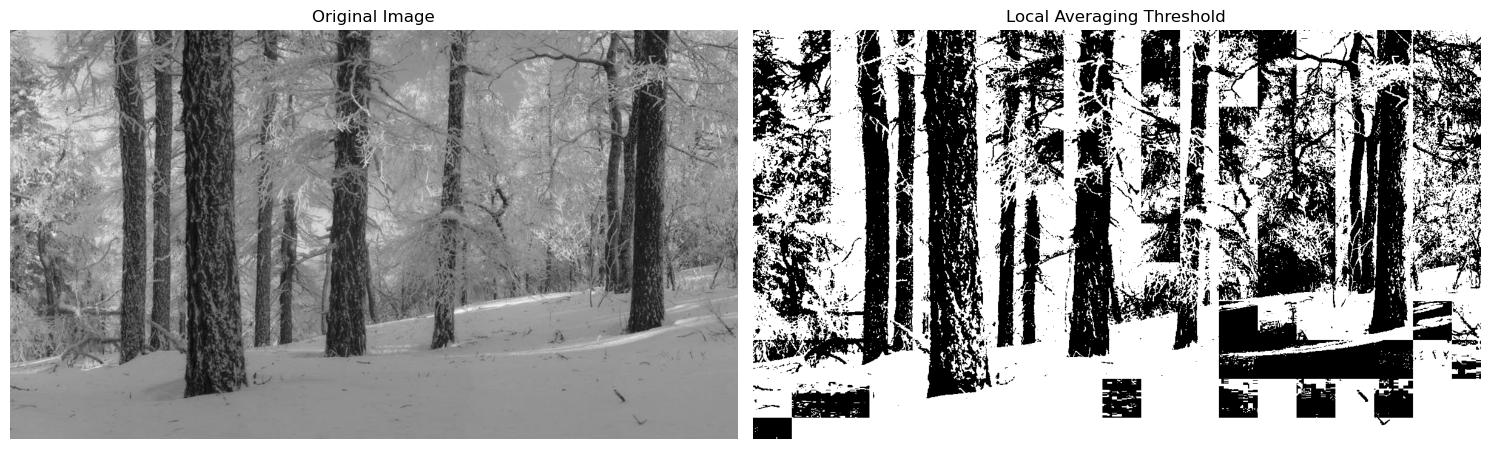

In [28]:
def local_averaging_threshold_method(img, block_size=64, initial_threshold=128, delta=0.5, max_iterations=100):
    height, width = img.shape
    binary_img = np.zeros_like(img, dtype=np.uint8)
    threshold_map = np.zeros_like(img, dtype=np.float32)
    
    for y in range(0, height, block_size):
        for x in range(0, width, block_size):
            y_end = min(y + block_size, height)
            x_end = min(x + block_size, width)
            block = img[y:y_end, x:x_end]
            if block.size == 0:
                continue
            S = initial_threshold
            iteration = 0
            
            while iteration < max_iterations:
                class1 = block[block >= S]  
                class2 = block[block < S]  
                m1 = np.mean(class1) if len(class1) > 0 else 0
                m2 = np.mean(class2) if len(class2) > 0 else 0
                S_new = (m1 + m2) / 2
                if abs(S - S_new) < delta:
                    S = S_new
                    break
                S = S_new
                iteration += 1
            
            block_binary = np.where(block >= S, 1, 0).astype(np.uint8)
            binary_img[y:y_end, x:x_end] = block_binary
            threshold_map[y:y_end, x:x_end] = S
    
    return binary_img, threshold_map

def overlapping_local_averaging_threshold(img, block_size=64, overlap=16, initial_threshold=128, delta=0.5):
    height, width = img.shape
    step = block_size - overlap
    binary_accumulator = np.zeros_like(img, dtype=np.float32)
    weight_accumulator = np.zeros_like(img, dtype=np.float32)
    y_indices, x_indices = np.meshgrid(np.arange(block_size), np.arange(block_size), indexing='ij')
    center = block_size // 2
    weights = np.exp(-((x_indices - center)**2 + (y_indices - center)**2) / (2 * (block_size/4)**2))
    for y in range(0, height - block_size + 1, step):
        for x in range(0, width - block_size + 1, step):
            block = img[y:y + block_size, x:x + block_size]
            S = initial_threshold
            iteration = 0
            max_iterations = 100
            
            while iteration < max_iterations:
                class1 = block[block >= S]
                class2 = block[block < S]
                m1 = np.mean(class1) if len(class1) > 0 else 0
                m2 = np.mean(class2) if len(class2) > 0 else 0
                S_new = (m1 + m2) / 2
                
                if abs(S - S_new) < delta:
                    S = S_new
                    break
                
                S = S_new
                iteration += 1
            
            block_binary = np.where(block >= S, 1, 0).astype(np.float32)
            binary_accumulator[y:y + block_size, x:x + block_size] += block_binary * weights
            weight_accumulator[y:y + block_size, x:x + block_size] += weights
    
    binary_img = np.where(binary_accumulator / weight_accumulator > 0.5, 1, 0).astype(np.uint8)
    
    return binary_img

def adaptive_local_averaging_threshold(img, min_block_size=32, max_block_size=128, initial_threshold=128, delta=0.5):
    height, width = img.shape
    binary_img = np.zeros_like(img, dtype=np.uint8)
    variance = cv2.Laplacian(img.astype(np.float32), cv2.CV_32F) ** 2
    variance = cv2.GaussianBlur(variance, (5, 5), 0)
    var_min, var_max = variance.min(), variance.max()
    if var_max > var_min:
        variance = (variance - var_min) / (var_max - var_min)
    
    for y in range(0, height, min_block_size):
        for x in range(0, width, min_block_size):
            # Determine block size based on local variance
            y_end = min(y + max_block_size, height)
            x_end = min(x + max_block_size, width)
            block_var = np.mean(variance[y:y_end, x:x_end])
            
            # Higher variance -> smaller blocks for more detail
            block_size = int(max_block_size * (1 - block_var) + min_block_size * block_var)
            block_size = max(min_block_size, min(block_size, max_block_size))
            
            # Ensure block doesn't go beyond image boundaries
            actual_y_end = min(y + block_size, height)
            actual_x_end = min(x + block_size, width)
            
            block = img[y:actual_y_end, x:actual_x_end]
            
            if block.size == 0:
                continue
            
            # Apply averaging threshold method
            S = initial_threshold
            iteration = 0
            
            while iteration < 100:
                class1 = block[block >= S]
                class2 = block[block < S]
                m1 = np.mean(class1) if len(class1) > 0 else 0
                m2 = np.mean(class2) if len(class2) > 0 else 0
                S_new = (m1 + m2) / 2
                
                if abs(S - S_new) < delta:
                    S = S_new
                    break
                
                S = S_new
                iteration += 1
            
            # Apply threshold to block
            binary_img[y:actual_y_end, x:actual_x_end] = np.where(block >= S, 1, 0).astype(np.uint8)
    
    return binary_img



binary_result, threshold_map = local_averaging_threshold_method(image, block_size=64, initial_threshold=128, delta=0.5)

# Display results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(binary_result, cmap='gray')
axes[1].set_title('Local Averaging Threshold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

C:\Users\CorteC\AppData\Local\Temp\ipykernel_20064\639748826.py:67: RuntimeWarning: invalid value encountered in divide
  binary_img = np.where(binary_accumulator / weight_accumulator > 0.5, 1, 0).astype(np.uint8)


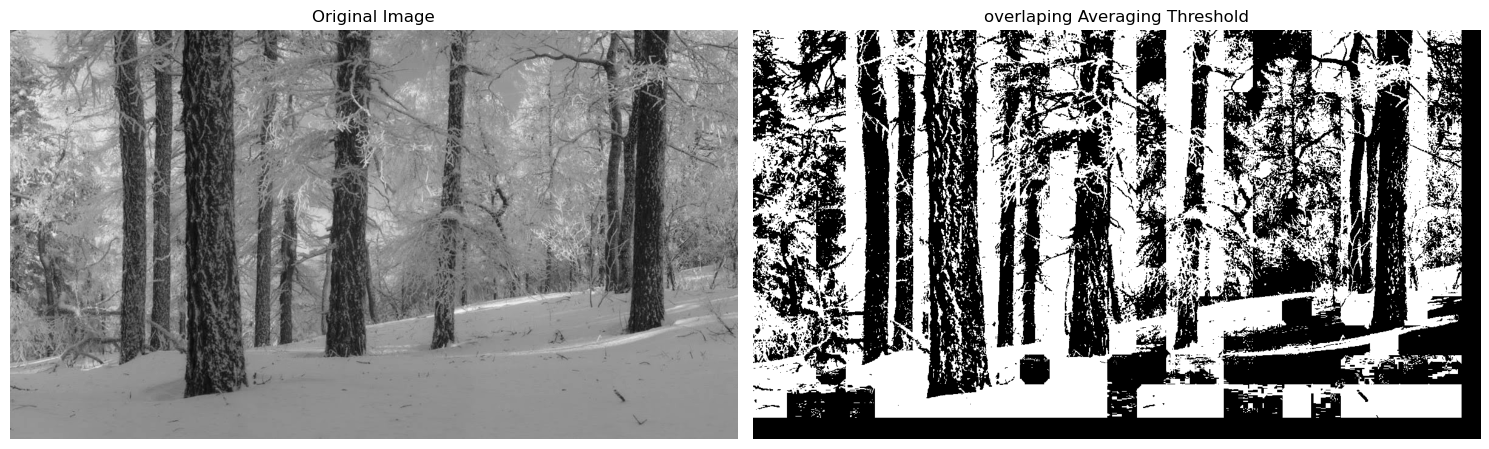

In [ ]:
binary_result=overlapping_local_averaging_threshold(image, block_size=64,overlap=16 ,  initial_threshold=128, delta=0.5)

# Display results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(binary_result, cmap='gray')
axes[1].set_title('overlapping Averaging Threshold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

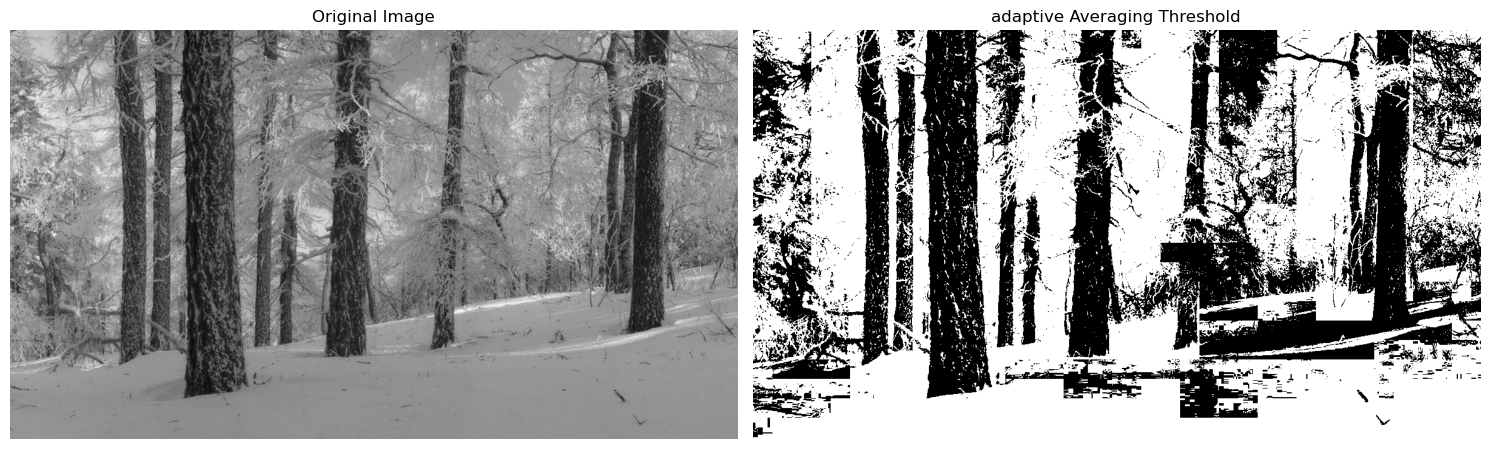

In [30]:
binary_result=adaptive_local_averaging_threshold(image, min_block_size=32, max_block_size=128, initial_threshold=128, delta=0.5)

# Display results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(binary_result, cmap='gray')
axes[1].set_title('adaptive Averaging Threshold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

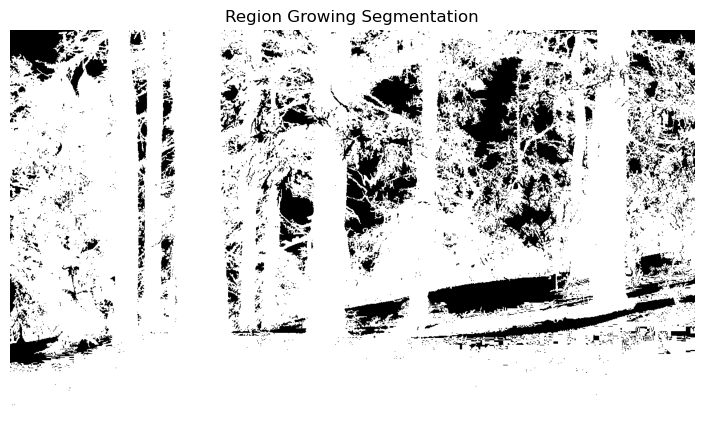

In [46]:
def region_growing(img, seeds, threshold, connectivity):
    
    height, width = img.shape
    segmentation = np.zeros((height, width), dtype=np.uint8)
    visited = np.zeros((height, width), dtype=np.bool_)
    if connectivity == 4:
        neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    else: 
        neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1),
                     (-1, -1), (-1, 1), (1, -1), (1, 1)]

    for seed in seeds:
        if isinstance(seed, tuple) or isinstance(seed, list):
            y, x = seed
            if y < 0 or y >= height or x < 0 or x >= width:
                continue
                
            if visited[y, x]:
                continue
                
            seed_intensity = float(img[y, x])
            queue = deque([(y, x)])
            visited[y, x] = True
            
            while queue:
                current_y, current_x = queue.popleft()
                segmentation[current_y, current_x] = 1
                
                for dy, dx in neighbors:
                    ny, nx = current_y + dy, current_x + dx
                    
                    
                    if 0 <= ny < height and 0 <= nx < width and not visited[ny, nx]:
                        neighbor_intensity = float(img[ny, nx])
                        
                        
                        if abs(neighbor_intensity - seed_intensity) <= threshold:
                            visited[ny, nx] = True
                            queue.append((ny, nx))
    
    return segmentation

segmented_image = region_growing(image, seeds=[(200 , 200), (100 , 100)], threshold=70, connectivity=8)
plt.figure(figsize=(10, 5))
plt.imshow(segmented_image, cmap='gray')
plt.title('Region Growing Segmentation')
plt.axis('off')
plt.show()

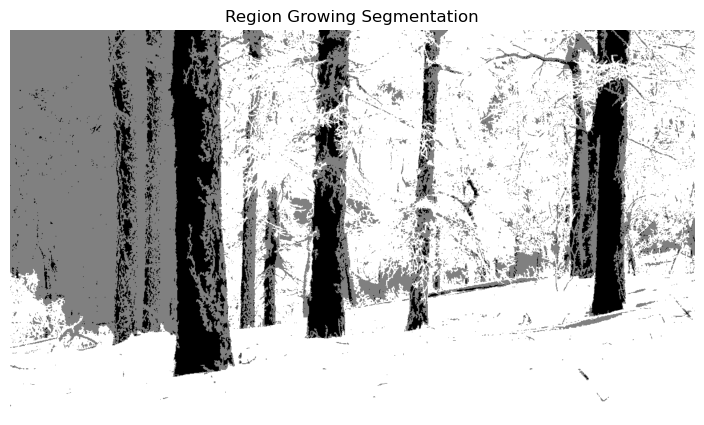

In [47]:
def automatic_seed_selection(img, method='gradient', num_seeds=5):
    
    height, width = img.shape
    seeds = []
    
    if method == 'gradient':
        sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
        gradient_mag = np.sqrt(sobelx**2 + sobely**2)
        flat_regions = gradient_mag < np.percentile(gradient_mag, 10)
        
        # Randomly select seeds from flat regions
        flat_points = np.column_stack(np.where(flat_regions))
        if len(flat_points) > 0:
            indices = np.random.choice(len(flat_points), min(num_seeds, len(flat_points)), replace=False)
            seeds = [(int(p[0]), int(p[1])) for p in flat_points[indices]]
    
    elif method == 'intensity':
        flat_img = img.flatten()
        dark_indices = np.argsort(flat_img)[:num_seeds//2]
        bright_indices = np.argsort(flat_img)[-num_seeds//2:]
        
        all_indices = np.concatenate([dark_indices, bright_indices])
        seeds = [(idx // width, idx % width) for idx in all_indices]
    
    return seeds


def multi_seed_region_growing(img, seeds, thresholds=None, connectivity=8):
    height, width = img.shape
    segmentation = np.zeros((height, width), dtype=np.int32)
    
    if thresholds is None:
        thresholds = [20] * len(seeds)
    elif isinstance(thresholds, (int, float)):
        thresholds = [thresholds] * len(seeds)
    
    if connectivity == 4:
        neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    else:
        neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1),
                     (-1, -1), (-1, 1), (1, -1), (1, 1)]
    
    for region_id, (seed, threshold) in enumerate(zip(seeds, thresholds), 1):
        y, x = seed
        if y < 0 or y >= height or x < 0 or x >= width:
            continue
            
        seed_intensity = float(img[y, x])
        region_mask = np.zeros((height, width), dtype=np.bool_)
        
        queue = deque([(y, x)])
        region_mask[y, x] = True
        
        while queue:
            current_y, current_x = queue.popleft()
            
            for dy, dx in neighbors:
                ny, nx = current_y + dy, current_x + dx
                
                if 0 <= ny < height and 0 <= nx < width and not region_mask[ny, nx]:
                    neighbor_intensity = float(img[ny, nx])
                    
                    if abs(neighbor_intensity - seed_intensity) <= threshold:
                        region_mask[ny, nx] = True
                        queue.append((ny, nx))
        
        segmentation[region_mask] = region_id
    
    return segmentation
seeds = automatic_seed_selection(image, method='gradient', num_seeds=5)
segmented_image = multi_seed_region_growing(image, seeds, thresholds=[70, 30], connectivity=4)
plt.figure(figsize=(10, 5))
plt.imshow(segmented_image, cmap='gray')
plt.title('Region Growing Segmentation')
plt.axis('off')
plt.show()

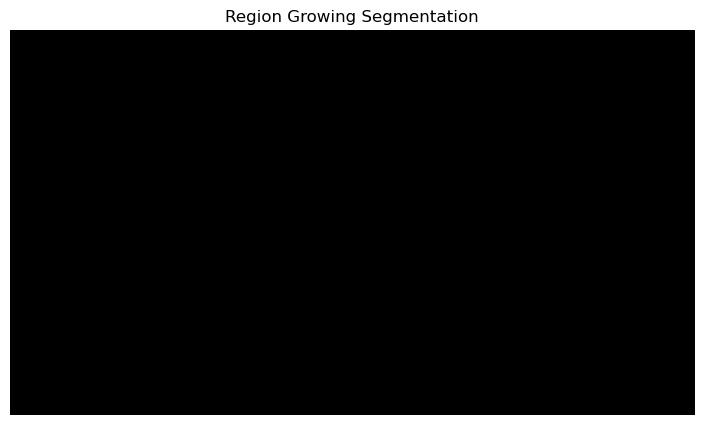

In [49]:
def region_growing_with_features(img, seeds, feature_threshold=20,  use_gradient=True, use_texture=False, connectivity=8):
    
    height, width = img.shape
    segmentation = np.zeros((height, width), dtype=np.uint8)
    visited = np.zeros((height, width), dtype=np.bool_)
    features = {}
    features['intensity'] = img.astype(np.float32)
    
    if use_gradient:
        sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
        features['gradient'] = np.sqrt(sobelx**2 + sobely**2)
    
    if use_texture:
        kernel = np.ones((3, 3)) / 9
        mean = cv2.filter2D(img.astype(np.float32), -1, kernel)
        variance = cv2.filter2D((img.astype(np.float32) - mean)**2, -1, kernel)
        features['texture'] = np.sqrt(variance)
    
    # Connectivity
    if connectivity == 4:
        neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    else:
        neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1),
                     (-1, -1), (-1, 1), (1, -1), (1, 1)]
    
    for seed in seeds:
        y, x = seed
        if y < 0 or y >= height or x < 0 or x >= width or visited[y, x]:
            continue
        
        seed_features = {}
        for feature_name, feature_map in features.items():
            seed_features[feature_name] = float(feature_map[y, x])
        
        queue = deque([(y, x)])
        visited[y, x] = True
        
        while queue:
            current_y, current_x = queue.popleft()
            segmentation[current_y, current_x] = 1
            
            for dy, dx in neighbors:
                ny, nx = current_y + dy, current_x + dx
                
                if 0 <= ny < height and 0 <= nx < width and not visited[ny, nx]:
                    
                    similarity_score = 0
                    num_features = 0
                    
                    for feature_name, feature_map in features.items():
                        seed_val = seed_features[feature_name]
                        neighbor_val = float(feature_map[ny, nx])
                        
                       
                        if feature_name == 'intensity':
                            diff = abs(neighbor_val - seed_val) / 255.0
                        else:
                            diff = abs(neighbor_val - seed_val) / (feature_map.max() + 1e-6)
                        
                        similarity_score += diff
                        num_features += 1
                    
                    avg_similarity = similarity_score / num_features
                    
                    similarity = 1 - avg_similarity
                    
                    if similarity * 255 >= feature_threshold:
                        visited[ny, nx] = True
                        queue.append((ny, nx))
    
    return segmentation
segmented_image = region_growing_with_features(image, seeds, feature_threshold=70, use_gradient=True, use_texture=False, connectivity=8)
plt.figure(figsize=(10, 5))
plt.imshow(segmented_image, cmap='gray')
plt.title('Region Growing Segmentation')
plt.axis('off')
plt.show()